# EDIS 8100 · Week 3 · Ethics and Bias Audit

## Auditing an at-risk model before anyone acts on it

**Estimated time: 30 minutes (in-class launch)**

Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia

---

## 🎯 What you will be able to do

By the end of this notebook you will be able to:

1. **Train** a simple at-risk prediction model on learning management system activity data, and read its accuracy honestly against a do-nothing baseline.
2. **Disaggregate** the model's errors by student group, computing false positive and false negative rates for first generation students and for students who work long hours.
3. **Explain**, with evidence from the data, how a model can be accurate overall and still be unfair, and point to the exact decision where the unfairness entered.
4. **Redesign** the feature set, re-run the same audit, and say what the redesign fixed and what it did not.

## How this notebook works

This is a running notebook, not a coding test. Here is everything you need to know:

- **Run the cells in order, top to bottom.** Press `Shift+Enter`, or click the play button to the left of a cell.
- **Nothing here can break your computer,** and nothing here touches a real student. The roster is invented.
- **If something looks broken, start over from the top.** In Colab: `Runtime > Restart and run all`. In Jupyter: `Kernel > Restart & Run All`. That fixes almost everything.
- **You do not have to write any code to finish the core path.** Read, run, look, interpret. The cells marked ✏️ **Your turn** already contain a working answer, so the notebook runs start to finish untouched. Change them when you are ready, and re-run just that cell.
- **The bold questions after each chart are for the person sitting next to you,** not for a grade. Say your answer out loud before you scroll.

If you have never written a line of code: you are exactly who this notebook was built for. Your job today is to be the skeptical reader of someone else's model, and that job needs your judgment, not your syntax.

## ⚙️ Setup: run the next cell first

The cell below builds this week's three synthetic datasets (`students.csv`, `lms_clickstream.csv`, `gradebook.csv`) inside this runtime. There is nothing to download, nothing to install, and nothing to log into.

The data are synthetic on purpose. Early warning systems are built on records that real students never agreed to hand over, and a class exercise is a poor reason to touch someone's transcript. So we invented a course instead. The ask in return is simple: **treat this roster as if it were real.**

In [1]:
# This cell is long on purpose. It is the data generator, pasted in so that this
# notebook works in Colab with no downloads and no accounts.
# You do not need to read it. Collapse it with the arrow on the left, run it once,
# and move on to section 1.

"""EDIS 8100 data generation, the subset needed for week03.
Extracted verbatim from data/generate_all_data.py so the numbers match the
canonical course datasets exactly. Seeds and helper functions are unchanged.
"""
from __future__ import annotations
import argparse
import time
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 8100
SEED_STUDENTS = SEED + 0
SEED_CLICKSTREAM = SEED + 1
SEED_GRADEBOOK = SEED + 2
DEFAULT_OUTDIR = Path('data')
N_STUDENTS = 120
N_GROUPS = 24
N_WEEKS = 8
COURSE_START = np.datetime64("2026-09-07T00:00:00")
DAY_S = 86400
QUIZ_DEADLINE_DAY = {k: 7 * k + 1 for k in range(1, N_WEEKS + 1)}
FINAL_PROJECT_DEADLINE_DAY = 64  # Tuesday 2026-11-10
STUDENT_COLS = [
    "student_id",
    "first_name",
    "last_name",
    "gender",
    "first_gen",
    "multilingual",
    "work_hours_per_week",
    "prior_gpa",
    "major_area",
]
def _outpath(outdir, filename: str) -> Path:
    path = Path(outdir).expanduser().resolve()
    path.mkdir(parents=True, exist_ok=True)
    return path / filename
def _ts(seconds_from_start) -> np.ndarray:
    """Seconds since COURSE_START to datetime64[s]."""
    secs = np.asarray(seconds_from_start, dtype="float64")
    return COURSE_START + np.round(secs).astype("int64").astype("timedelta64[s]")
def _iso(dt64) -> pd.Series:
    """Format datetime64 values as ISO 8601 strings without fractional seconds."""
    return pd.Series(pd.to_datetime(np.asarray(dt64))).dt.strftime("%Y-%m-%dT%H:%M:%S")
def _z(x) -> np.ndarray:
    x = np.asarray(x, dtype="float64")
    sd = x.std()
    return (x - x.mean()) / (sd if sd > 0 else 1.0)
def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype="float64")))
def _correlated(rng, base: np.ndarray, r: float) -> np.ndarray:
    """A standard normal vector correlated with `base` at approximately r."""
    noise = rng.normal(0, 1, base.size)
    return r * base + np.sqrt(max(0.0, 1.0 - r * r)) * noise
FIRST_NAMES_WOMAN = [
    "Aaliyah", "Sofia", "Mei", "Priya", "Emma", "Zara", "Isabella", "Hana",
    "Grace", "Amara", "Leila", "Camila", "Nia", "Yuki", "Ruth", "Elena",
    "Tanvi", "Noor", "Bridget", "Maya", "Ines", "Anika", "Kaia", "Rosa",
    "Delphine", "Simone", "Adaeze", "Lucia", "Hafsa", "Marta", "Thandiwe",
    "Colette", "Fatima", "Beatriz", "Solveig", "Imani",
]
FIRST_NAMES_MAN = [
    "Elijah", "Diego", "Ravi", "Omar", "Noah", "Tobias", "Malik", "Kenji",
    "Andre", "Samuel", "Hugo", "Nikhil", "Ivan", "Caleb", "Mateo", "Youssef",
    "Liam", "Dmitri", "Jonas", "Tariq", "Peter", "Wen", "Ezra", "Rafael",
    "Bilal", "Soren", "Kwame", "Julian", "Arun", "Felix", "Mikael", "Hector",
    "Devon", "Idris", "Lorenzo", "Emeka",
]
FIRST_NAMES_NONBINARY = [
    "Avery", "Rowan", "Quinn", "Sasha", "Jules", "Kai", "Ari", "Reese",
    "Emery", "Noel", "Marlowe", "Sage",
]
LAST_NAMES = [
    "Alvarez", "Nakamura", "Okoro", "Bennett", "Silva", "Petrov", "Haddad",
    "Nguyen", "Kowalski", "O'Neill", "Rahman", "Fitzgerald", "Mbeki", "Larsen",
    "Duarte", "Chowdhury", "Vasquez", "Kim", "Delgado", "Whitfield", "Osei",
    "Ramirez", "Baptiste", "Lindqvist", "Serrano", "Tran", "Abebe", "Moreau",
    "Castillo", "Yamada", "Hollis", "Bright", "Novak", "Iyer", "Sandoval",
    "Keller", "Adeyemi", "Marchetti", "Villanueva", "Sokolov", "Barros",
    "Ferreira", "Nwosu", "Hassan", "Blackwell", "Mendoza", "Park", "Rossi",
    "Grant", "Solano", "Achebe", "Bauer", "Cruz", "Dawson", "Egan", "Farrell",
]
MAJOR_AREAS = [
    "education", "psychology", "data science", "nursing", "engineering", "humanities",
]
MAJOR_PROBS = [0.30, 0.22, 0.12, 0.15, 0.09, 0.12]
def make_students(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Build the 120 students of EDUC 1010 and their latent traits.

    Writes students.csv (the nine documented columns only). The returned frame
    also carries the latent traits that every other generator needs. Latents are
    never written to disk: students in the course are supposed to discover the
    planted structure, not read it off a column.
    """
    rng = np.random.default_rng(SEED_STUDENTS)
    n = N_STUDENTS

    student_id = np.array([f"S{i + 1:03d}" for i in range(n)])

    # Core latent traits.
    ability = rng.normal(0, 1, n)                       # what the assessments track
    engagement = _correlated(rng, ability, 0.20)        # how much they click
    srl_skill = _correlated(rng, ability, 0.35)         # planning, monitoring, reflecting
    procrastination = -0.42 * srl_skill + np.sqrt(1 - 0.42**2) * rng.normal(0, 1, n)
    # Regularity is how many separate days a student touches the course. It helps
    # learning, and it is also the feature the naive at-risk model leans on.
    regularity = 0.35 * engagement + 0.30 * srl_skill + 0.85 * rng.normal(0, 1, n)
    talkativeness = rng.normal(0, 1, n)                 # studio floor time
    chat_propensity = 0.30 * talkativeness + 0.95 * rng.normal(0, 1, n)
    doc_propensity = rng.normal(0, 1, n)
    forum_propensity = 0.30 * engagement + np.sqrt(1 - 0.30**2) * rng.normal(0, 1, n)

    # Demographics.
    gender = rng.choice(["woman", "man", "nonbinary"], size=n, p=[0.61, 0.34, 0.05])
    first_gen = (rng.random(n) < 0.30).astype(int)
    multilingual = (rng.random(n) < 0.24).astype(int)
    major_area = rng.choice(MAJOR_AREAS, size=n, p=MAJOR_PROBS)

    prior_gpa = np.clip(3.16 + 0.42 * ability + rng.normal(0, 0.17, n), 2.0, 4.0)
    prior_gpa = np.round(prior_gpa, 2)

    # Paid work. First generation students in this cohort work more hours, which
    # is what makes the naive at-risk model in week 3 go wrong.
    work_raw = rng.gamma(1.9, 4.3, n) + first_gen * rng.uniform(5.0, 14.0, n)
    work_hours = np.clip(np.round(work_raw), 0, 30).astype(int)

    # P2 group: works 15+ hours, first generation, studies in concentrated bursts.
    burst_worker = ((first_gen == 1) & (work_hours >= 15)).astype(int)

    # P1 group: high ability, low clickstream volume. The "efficient" cluster.
    efficient = np.zeros(n, dtype=int)
    eligible = np.where((ability > 0.28) & (burst_worker == 0))[0]
    efficient[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # P6 group: requests hints in rapid bursts instead of working the problem.
    hint_spam = np.zeros(n, dtype=int)
    eligible = np.where(srl_skill < 0.15)[0]
    hint_spam[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # Forum structure for P4: three loose clusters plus four bridge builders.
    community = np.tile(np.arange(3), int(np.ceil(n / 3)))[:n]
    rng.shuffle(community)

    silent_forum = (forum_propensity < np.quantile(forum_propensity, 0.18)).astype(int)

    fp_rank = forum_propensity.argsort().argsort() / (n - 1)
    connector = np.zeros(n, dtype=int)
    conn_pool = np.where((fp_rank > 0.45) & (fp_rank < 0.74) & (silent_forum == 0))[0]
    chosen = []
    for comm in [0, 1, 2]:
        opts = [i for i in conn_pool if community[i] == comm]
        if opts:
            chosen.append(int(rng.choice(opts)))
    remaining = [i for i in conn_pool if i not in chosen]
    while len(chosen) < 4 and remaining:
        pick = int(rng.choice(remaining))
        chosen.append(pick)
        remaining.remove(pick)
    connector[np.array(chosen, dtype=int)] = 1

    # Studio groups of five. Multilingual students are dealt round robin so that
    # no group ends up as an artifact of the assignment procedure.
    order = np.lexsort((rng.random(n), -multilingual))
    group_index = np.empty(n, dtype=int)
    group_index[order] = np.arange(n) % N_GROUPS
    group_id = np.array([f"G{g + 1:02d}" for g in group_index])

    # Names. Keep full names unique so student_id is never ambiguous in class.
    first_name = np.empty(n, dtype=object)
    last_name = np.empty(n, dtype=object)
    used = set()
    for i in range(n):
        if gender[i] == "woman":
            bank = FIRST_NAMES_WOMAN
        elif gender[i] == "man":
            bank = FIRST_NAMES_MAN
        else:
            bank = FIRST_NAMES_NONBINARY
        for _ in range(400):
            fn = str(rng.choice(bank))
            ln = str(rng.choice(LAST_NAMES))
            if (fn, ln) not in used:
                break
        used.add((fn, ln))
        first_name[i] = fn
        last_name[i] = ln

    df = pd.DataFrame(
        {
            "student_id": student_id,
            "first_name": first_name,
            "last_name": last_name,
            "gender": gender,
            "first_gen": first_gen,
            "multilingual": multilingual,
            "work_hours_per_week": work_hours,
            "prior_gpa": prior_gpa,
            "major_area": major_area,
            # latent traits below this line, never written to CSV
            "ability": ability,
            "engagement": engagement,
            "srl_skill": srl_skill,
            "procrastination": procrastination,
            "regularity": regularity,
            "talkativeness": talkativeness,
            "chat_propensity": chat_propensity,
            "doc_propensity": doc_propensity,
            "forum_propensity": forum_propensity,
            "efficient": efficient,
            "burst_worker": burst_worker,
            "hint_spam": hint_spam,
            "community": community,
            "connector": connector,
            "silent_forum": silent_forum,
            "group_id": group_id,
        }
    )

    if write:
        df[STUDENT_COLS].to_csv(_outpath(outdir, "students.csv"), index=False)
    return df
EVENT_TYPES = [
    "login", "page_view", "video_play", "video_pause",
    "forum_view", "assignment_view", "submit",
]
EVENT_BASE_P = np.array([0.12, 0.32, 0.16, 0.11, 0.13, 0.11, 0.05])
def make_clickstream(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """LMS event log for the eight course weeks.

    Two things vary across students and they are not the same thing. Volume is how
    many events a student generates, and it is heavy tailed. Regularity is how many
    separate days they show up at all. The week also has a rhythm: Monday and
    Tuesday spike ahead of the Tuesday night quiz deadline.

    Two subgroups break the "more clicks means more learning" story. Efficient
    students generate few events and score well (P1). First generation students
    working 15+ hours can only touch the course on a handful of days, so their
    regularity looks terrible even though their learning does not (P2).
    """
    rng = np.random.default_rng(SEED_CLICKSTREAM)
    students = make_students(write=False)
    n = len(students)

    ability = students["ability"].to_numpy()
    engagement = students["engagement"].to_numpy()
    procrast = students["procrastination"].to_numpy()
    regularity_z = _z(students["regularity"].to_numpy())
    efficient = students["efficient"].to_numpy()
    burst = students["burst_worker"].to_numpy()

    # Expected event count per student, lognormal so the tail is heavy.
    log_mu = (
        5.78
        + 0.40 * engagement
        + 0.05 * ability
        + 0.10 * regularity_z
        + np.log(np.where(efficient == 1, 0.30, 1.0))
        + np.log(np.where(burst == 1, 0.95, 1.0))
    )
    n_events = np.clip(
        np.round(np.exp(log_mu + rng.normal(0, 0.18, n))), 25, 4000
    ).astype(int)

    n_days = N_WEEKS * 7
    day_index = np.arange(n_days)
    weekday = (day_index + 0) % 7  # 0 = Monday, because 2026-09-07 is a Monday
    weekday_weight = np.array([1.45, 1.60, 1.10, 1.00, 0.75, 0.60, 1.05])
    weekday_rel = weekday_weight / weekday_weight.mean()
    week_of = day_index // 7
    week_weight = 1.0 - 0.022 * week_of  # attention fades a little across the term
    base_day_w = weekday_weight[weekday] * week_weight

    # Probability that a given student touches the course on a given day.
    p_active = _sigmoid(0.45 + 0.95 * regularity_z)
    # Working 15+ hours compresses the week into a couple of long evenings.
    p_active = np.where(burst == 1, p_active * 0.18, p_active)

    # Submit events crowd into the 48 hours before each Tuesday deadline.
    submit_day_w = np.where(np.isin(weekday, [0, 1]), 5.0, 0.70) * week_weight

    rows_student, rows_day, rows_type = [], [], []
    rows_hour = []

    for i in range(n):
        k = int(n_events[i])
        day_p = np.clip(p_active[i] * weekday_rel[weekday] * week_weight, 0.01, 0.97)
        active = rng.random(n_days) < day_p
        if active.sum() < 4:
            active[rng.choice(n_days, size=4, replace=False)] = True

        w = base_day_w * active * (0.55 + rng.gamma(3.0, 1.0 / 3.0, n_days))
        w = w / w.sum()
        sw = submit_day_w * active
        sw = sw / sw.sum()

        # Per-student taste for videos versus pages versus the forum.
        p_types = rng.dirichlet(EVENT_BASE_P * 55.0)
        types = rng.choice(len(EVENT_TYPES), size=k, p=p_types)

        days = rng.choice(n_days, size=k, p=w)
        is_submit = types == EVENT_TYPES.index("submit")
        if is_submit.any():
            days[is_submit] = rng.choice(n_days, size=int(is_submit.sum()), p=sw)

        # Time of day: three loose study sessions, later for procrastinators.
        centers = rng.choice(
            [9.6, 14.2, 20.8], size=k, p=[0.27, 0.33, 0.40]
        ) + 1.05 * procrast[i] * rng.random(k)
        hours = centers + rng.normal(0, 0.85, k)
        hours = np.clip(hours, 0.02, 23.97)

        rows_student.append(np.full(k, i))
        rows_day.append(days)
        rows_type.append(types)
        rows_hour.append(hours)

    student_idx = np.concatenate(rows_student)
    days = np.concatenate(rows_day)
    types = np.concatenate(rows_type)
    hours = np.concatenate(rows_hour)

    seconds = days * DAY_S + hours * 3600.0
    order = np.argsort(seconds, kind="stable")
    student_idx, days, types, seconds = (
        student_idx[order], days[order], types[order], seconds[order]
    )

    week = (days // 7 + 1).astype(int)
    type_names = np.array(EVENT_TYPES)[types]

    # Plausible resource ids per event type.
    resource = np.empty(seconds.size, dtype=object)
    page_no = rng.integers(1, 9, seconds.size)
    video_no = rng.integers(1, 5, seconds.size)
    thread_no = rng.integers(1, 61, seconds.size)
    for t, name in enumerate(EVENT_TYPES):
        mask = types == t
        if not mask.any():
            continue
        if name == "login":
            resource[mask] = "lms_home"
        elif name == "page_view":
            resource[mask] = [
                f"w{w}_page_{p:02d}" for w, p in zip(week[mask], page_no[mask])
            ]
        elif name in ("video_play", "video_pause"):
            resource[mask] = [
                f"w{w}_video_{v:02d}" for w, v in zip(week[mask], video_no[mask])
            ]
        elif name == "forum_view":
            resource[mask] = [f"thread_{t3:03d}" for t3 in thread_no[mask]]
        else:  # assignment_view and submit both point at the next quiz due
            deadline_days = np.array([QUIZ_DEADLINE_DAY[k] for k in range(1, N_WEEKS + 1)])
            next_quiz = np.clip(
                1 + np.searchsorted(deadline_days, days[mask], side="left"), 1, N_WEEKS
            )
            resource[mask] = [f"quiz_{k}" for k in next_quiz]

    df = pd.DataFrame(
        {
            "event_id": [f"E{i + 1:06d}" for i in range(seconds.size)],
            "student_id": students["student_id"].to_numpy()[student_idx],
            "timestamp": _iso(_ts(seconds)),
            "week": week,
            "event_type": type_names,
            "resource_id": resource,
        }
    )
    if write:
        df.to_csv(_outpath(outdir, "lms_clickstream.csv"), index=False)
    return df
QUIZ_DIFFICULTY = np.array([2.2, 0.4, -3.1, -0.8, 1.1, -2.4, 0.2, 1.4])
def make_gradebook(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Eight quizzes plus a final project, with submission and deadline stamps.

    Two planted structures live here. Quiz to quiz improvement tracks self
    regulated learning skill and is flattest for the hint spam subgroup (P6,
    completed by srl_traces.csv). Submission timing tracks procrastination, which
    also drags scores down, so last minute submissions score lower (P3). The link
    is correlational by construction: nothing about submitting late causes the
    lower score, which is exactly the inference students should have to argue about.
    """
    rng = np.random.default_rng(SEED_GRADEBOOK)
    students = make_students(write=False)
    n = len(students)

    ability = students["ability"].to_numpy()
    engagement = students["engagement"].to_numpy()
    srl = students["srl_skill"].to_numpy()
    procrast = students["procrastination"].to_numpy()
    hint_spam = students["hint_spam"].to_numpy()
    burst = students["burst_worker"].to_numpy()
    sid = students["student_id"].to_numpy()

    srl_z = _z(srl)
    procrast_z = _z(procrast)
    regularity_z = _z(students["regularity"].to_numpy())

    base = (
        76.0
        + 7.2 * ability
        + 1.9 * srl_z
        + 0.3 * engagement
        + 4.2 * regularity_z
        - 4.1 * procrast_z
        - 0.6 * burst
        + rng.normal(0, 2.0, n)
    )
    # Growth across the term: SRL loops pay off, hint spamming does not.
    slope = 0.68 * srl_z - 0.62 * hint_spam + 0.12 * ability + rng.normal(0, 0.35, n)

    rows = []
    for k in range(1, N_WEEKS + 1):
        raw = (
            base
            + slope * (k - 4.5)
            + QUIZ_DIFFICULTY[k - 1]
            + rng.normal(0, 6.0, n)
        )
        score = np.round(np.clip(raw, 32.0, 100.0), 1)

        deadline_s = QUIZ_DEADLINE_DAY[k] * DAY_S + 23 * 3600 + 59 * 60
        # Hours before the deadline: procrastinators cut it close.
        mu = 3.25 - 1.35 * procrast_z
        hours_before = np.exp(mu + rng.normal(0, 0.85, n))
        # A quiz cannot be submitted before it exists. It opens with its own
        # week, so the earliest possible submission is that week's first moment.
        # Saturating against that window leaves the last minute tail exactly as
        # drawn (1 - exp(-x) is x for small x) and only bends the early tail, so
        # nobody stacks up on the release instant.
        open_s = (k - 1) * 7 * DAY_S
        max_hours = (deadline_s - open_s) / 3600.0
        hours_before = max_hours * (1.0 - np.exp(-hours_before / max_hours))
        hours_before = np.clip(hours_before, 0.03, max_hours)
        # A few submissions land after the bell.
        late = rng.random(n) < (0.02 + 0.035 * _sigmoid(1.4 * procrast_z))
        hours_before = np.where(late, -rng.uniform(0.2, 11.0, n), hours_before)
        submit_s = deadline_s - hours_before * 3600.0

        rows.append(
            pd.DataFrame(
                {
                    "student_id": sid,
                    "assessment": f"quiz_{k}",
                    "score": score,
                    "submitted_at": _iso(_ts(submit_s)),
                    "deadline": _iso(_ts(np.full(n, deadline_s))),
                }
            )
        )

    quizzes = pd.concat(rows, ignore_index=True)

    mean_quiz = quizzes.groupby("student_id")["score"].mean().reindex(sid).to_numpy()
    fp_raw = 0.55 * mean_quiz + 0.45 * (77.0 + 7.0 * ability + 2.0 * srl_z) + rng.normal(0, 4.6, n)
    fp_score = np.round(np.clip(fp_raw, 40.0, 100.0), 1)
    fp_deadline_s = FINAL_PROJECT_DEADLINE_DAY * DAY_S + 23 * 3600 + 59 * 60
    fp_hours = np.clip(np.exp(3.05 - 1.2 * procrast_z + rng.normal(0, 0.8, n)), 0.05, 14 * 24)
    final_project = pd.DataFrame(
        {
            "student_id": sid,
            "assessment": "final_project",
            "score": fp_score,
            "submitted_at": _iso(_ts(fp_deadline_s - fp_hours * 3600.0)),
            "deadline": _iso(_ts(np.full(n, fp_deadline_s))),
        }
    )

    df = pd.concat([quizzes, final_project], ignore_index=True)
    df = df.sort_values(["student_id", "assessment"], kind="stable").reset_index(drop=True)
    if write:
        df.to_csv(_outpath(outdir, "gradebook.csv"), index=False)
    return df


def build_data(outdir='data'):
    import os
    os.makedirs(outdir, exist_ok=True)
    make_students(outdir=outdir)
    make_clickstream(outdir=outdir)
    make_gradebook(outdir=outdir)
    return outdir


build_data(outdir='data')
print('Data ready. Files created in ./data:')
import os
for f in sorted(os.listdir('data')): print('  ', f)


Data ready. Files created in ./data:
   gradebook.csv
   lms_clickstream.csv
   students.csv


## 📊 1. Build the table the model will see

An early warning model does not see a student. It sees a row of numbers. So the first thing worth auditing is the row.

We will build one row per student out of three sources:

- **Who they are**, from `students.csv`: including `first_gen`, `work_hours_per_week`, and `prior_gpa`.
- **What they did**, from `lms_clickstream.csv`: 41,117 raw events collapsed into per-student counts.
- **How they did**, from `gradebook.csv`: their mean score across the eight quizzes.

Two of the activity summaries do more work than they look like they do:

- `total_events` is **volume**: how much a student clicked, all term.
- `active_days` is **regularity**: how many distinct calendar days they showed up at all.

A student can have plenty of one and very little of the other. Hold on to that.

Finally we have to define the thing the model is asked to predict. Here, `at_risk = 1` means a mean quiz score below 70. That threshold is a choice, not a fact. In a real institution a number like it gets set once, in a meeting, and is rarely revisited by anyone who has to live with it.

In [2]:
%matplotlib inline
# the line above just tells the notebook to draw charts here on the page

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold

pd.set_option("display.width", 120)

# --- load the three files we built in the setup cell ---------------------
students = pd.read_csv("data/students.csv")
clicks = pd.read_csv("data/lms_clickstream.csv", parse_dates=["timestamp"])
grades = pd.read_csv("data/gradebook.csv")

# --- summarise the clickstream: one row per student ----------------------
clicks["day"] = clicks["timestamp"].dt.date

volume_and_spread = clicks.groupby("student_id").agg(
    total_events=("event_id", "count"),   # how MUCH they clicked
    active_days=("day", "nunique"),       # how MANY distinct days they showed up
)

# counts of each kind of event, one column per event_type
by_event_type = (
    clicks.pivot_table(index="student_id", columns="event_type",
                       values="event_id", aggfunc="count")
    .fillna(0)
    .astype(int)
)
by_event_type.columns.name = None
activity = volume_and_spread.join(by_event_type)

# --- outcome: mean quiz score (the final project is excluded) ------------
quizzes = grades[grades["assessment"].str.startswith("quiz_")]
mean_quiz = quizzes.groupby("student_id")["score"].mean().rename("mean_quiz")

# --- one row per student -------------------------------------------------
model_table = (
    students.set_index("student_id").join(activity).join(mean_quiz).reset_index()
)

RISK_CUTOFF = 70          # mean quiz score below this counts as "at risk"
model_table["at_risk"] = (model_table["mean_quiz"] < RISK_CUTOFF).astype(int)

print(f"Students: {len(model_table)}")
print(f"Labelled at risk (mean quiz < {RISK_CUTOFF}): {model_table['at_risk'].sum()}"
      f"  ({model_table['at_risk'].mean():.0%} of the class)")
print(f"Columns available to a model: {', '.join(activity.columns)}, prior_gpa\n")

model_table[["student_id", "first_gen", "work_hours_per_week", "prior_gpa",
             "total_events", "active_days", "submit", "mean_quiz", "at_risk"]].head(8)

Students: 120
Labelled at risk (mean quiz < 70): 34  (28% of the class)
Columns available to a model: total_events, active_days, assignment_view, forum_view, login, page_view, submit, video_pause, video_play, prior_gpa



,student_id,first_gen,work_hours_per_week,prior_gpa,total_events,active_days,submit,mean_quiz,at_risk
0,S001,1,23,3.38,338,7,11,81.4125,0
1,S002,1,16,3.38,341,4,29,69.8750,1
2,S003,1,29,3.03,218,7,4,73.3250,0
3,S004,0,9,2.92,591,29,40,74.1500,0
4,S005,0,3,3.00,269,37,3,70.1875,0
5,S006,1,13,3.63,157,32,8,92.1375,0
6,S007,0,5,3.56,428,26,28,71.6250,0
7,S008,1,22,2.49,356,7,8,79.3750,0


**Before you go on.** Look at how `at_risk` was defined. A student who struggles in week 2 and recovers by week 8 gets the same label as a student who struggles all term. A student at 69.9 and a student at 70.1 get opposite labels.

Turn to the person next to you: **who does that label flatten, and what would have to be in the data for you to tell those students apart?** Every model in this notebook inherits whatever this line got wrong.

## 📊 2. Train the model, then look at the accuracy

**Logistic regression in one sentence.** It finds the best available dividing line between the students who ended up at risk and the students who did not, and then hands back, for each student, a number between 0 and 1 that behaves like a probability of being at risk.

The activity-only feature set is deliberately ordinary. It is close to what a real vendor product would use, because click data is what a learning management system exports without anyone having to ask permission:

`total_events`, `active_days`, `video_play`, `forum_view`

Two decisions inside the next cell deserve to be said out loud, because in a deployed system nobody sees them:

**How we test it.** Five-fold cross validation: split the class into five parts, train on four, predict the fifth, rotate until every student has been predicted by a model that never saw them. Scoring a model on the same students it trained on is grading your own homework.

**How a score becomes an action.** A risk score does nothing by itself. Someone has to decide who gets the phone call. Our fictional advising office has the staff to reach 25 students this term, so we flag the 25 highest scores. That capacity number is the actual policy, and it is set by a budget, not by a model.

In [3]:
y_true = model_table["at_risk"].to_numpy()

def risk_scores(feature_names):
    """Fit a logistic regression and return an out-of-sample risk score per student.

    Every student's score comes from a model trained on the other four folds,
    so no student is ever scored by a model that already saw their outcome.
    """
    X = model_table[list(feature_names)].to_numpy(dtype=float)
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=8100)
    return cross_val_predict(model, X, y_true, cv=folds, method="predict_proba")[:, 1]

def flag_top_k(scores, k):
    """Flag the k highest-risk students: the advising office's caseload rule."""
    cutoff = np.sort(scores)[-k]
    return (scores >= cutoff).astype(int)

CASELOAD = 25
ACTIVITY_FEATURES = ["total_events", "active_days", "video_play", "forum_view"]

scores_activity = risk_scores(ACTIVITY_FEATURES)
flags_activity = flag_top_k(scores_activity, CASELOAD)

accuracy = (flags_activity == y_true).mean()
do_nothing = (y_true == 0).mean()   # accuracy of "never flag anybody"

print(f"Features used: {', '.join(ACTIVITY_FEATURES)}")
print(f"Students flagged for outreach: {flags_activity.sum()}\n")
print(f"Overall accuracy of the model .............. {accuracy:.3f}")
print(f"Accuracy of 'never flag anybody' .......... {do_nothing:.3f}")
print(f"Improvement over doing nothing ............ {accuracy - do_nothing:+.3f}\n")

confusion = pd.crosstab(
    pd.Series(np.where(y_true == 1, "truly at risk", "truly not at risk"), name="actual"),
    pd.Series(np.where(flags_activity == 1, "flagged", "not flagged"), name="model says"),
)
print(confusion.to_string())

Features used: total_events, active_days, video_play, forum_view
Students flagged for outreach: 25

Overall accuracy of the model .............. 0.742
Accuracy of 'never flag anybody' .......... 0.717
Improvement over doing nothing ............ +0.025

model says         flagged  not flagged
actual                                 
truly at risk           14           20
truly not at risk       11           75


**Pause here.** The model is right about roughly three students in four. The rule "never flag anybody" is right about seven in ten, costs nothing to build, and needs no data at all.

**Would you deploy this model? What would you want to know before you decided?** Notice that everything you have seen so far is a single number describing 120 people at once. A single number cannot tell you who absorbed the mistakes.

## 📊 3. The audit: who pays for the mistakes?

An overall accuracy number averages over everybody, which is exactly what makes it comfortable. To audit a model you have to break the errors apart and count each kind inside each group.

There are two ways to be wrong, and they land on different people:

| Error | Plain language | What it costs the student |
|---|---|---|
| **False positive** | Flagged, but was doing fine | Being watched, advised at, or labelled when you did not need it |
| **False negative** | Not flagged, but was struggling | Being invisible to a system that was built to help you |

So we compute two rates inside each group:

- **False positive rate**: of the students in this group who were **not** at risk, what share did the model flag anyway?
- **False negative rate**: of the students in this group who **were** at risk, what share did the model miss?

These rates are proportions, so 0.33 means one third. Watch the group sizes in the table as well: some of these cells hold only a couple of dozen students, and small cells wobble.

AUDIT OF THE ACTIVITY-ONLY MODEL
                       students  not at risk (n)  false positive rate  at risk (n)  false negative rate
group                                                                                                  
First generation             39               27                0.259           12                0.333
Continuing generation        81               59                0.068           22                0.727
Works 15+ hrs/week           40               30                0.267           10                0.200
Works under 15 hrs           80               56                0.054           24                0.750
First gen AND 15+ hrs        30               21                0.333            9                0.111
Everyone else                90               65                0.062           25                0.760


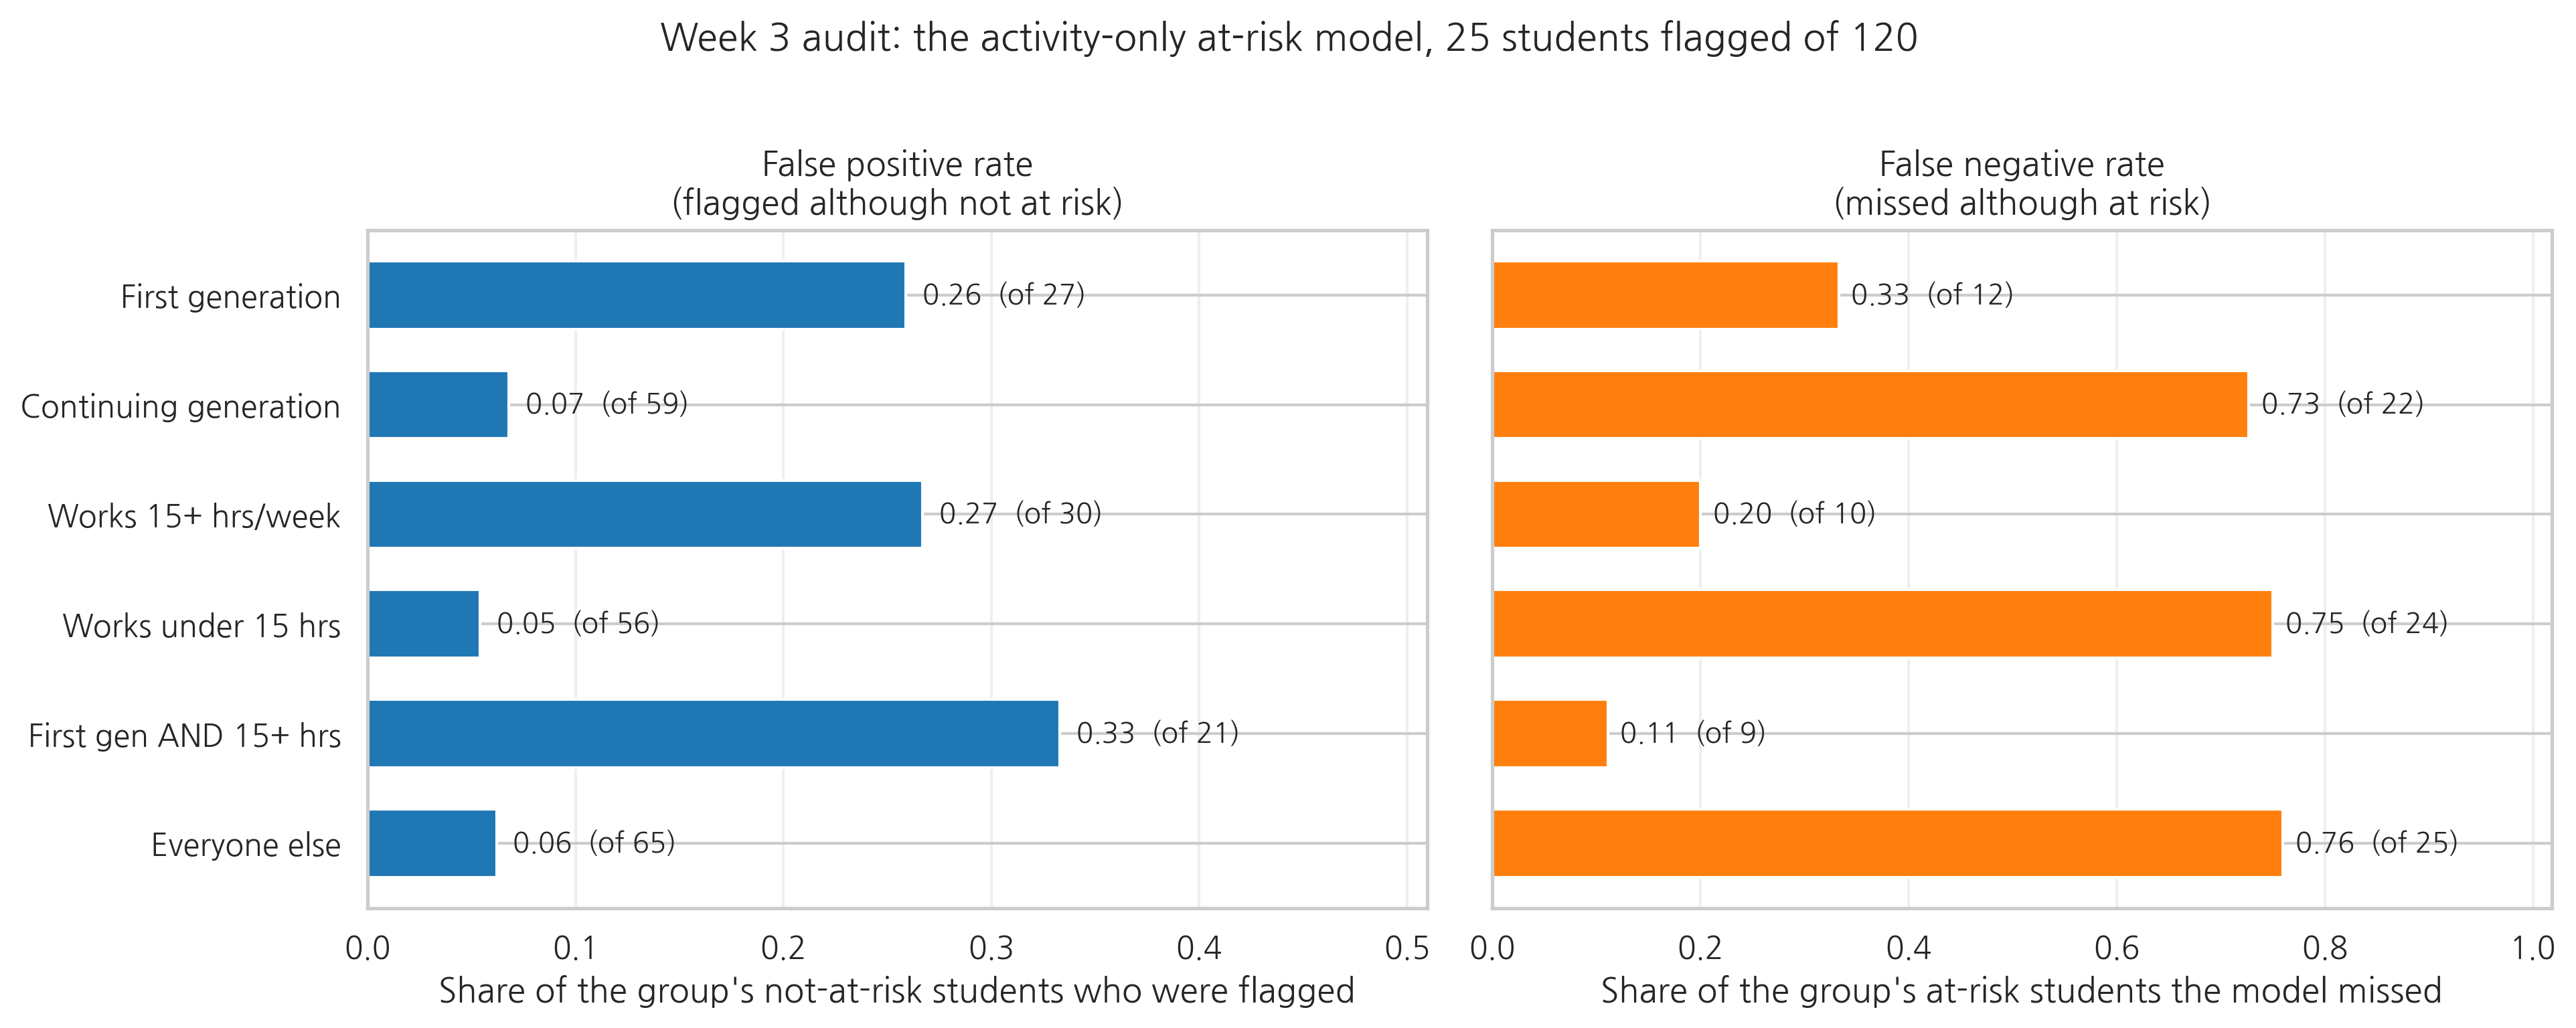

In [4]:
GROUPS = {
    "First generation":        (model_table["first_gen"] == 1).to_numpy(),
    "Continuing generation":   (model_table["first_gen"] == 0).to_numpy(),
    "Works 15+ hrs/week":      (model_table["work_hours_per_week"] >= 15).to_numpy(),
    "Works under 15 hrs":      (model_table["work_hours_per_week"] < 15).to_numpy(),
    "First gen AND 15+ hrs":   ((model_table["first_gen"] == 1) &
                                (model_table["work_hours_per_week"] >= 15)).to_numpy(),
    "Everyone else":           ~((model_table["first_gen"] == 1) &
                                 (model_table["work_hours_per_week"] >= 15)).to_numpy(),
}

def audit_table(flags, groups=GROUPS):
    """False positive and false negative rate inside each group."""
    rows = []
    for name, mask in groups.items():
        healthy = mask & (y_true == 0)     # in this group, truly NOT at risk
        struggling = mask & (y_true == 1)  # in this group, truly at risk
        rows.append({
            "group": name,
            "students": int(mask.sum()),
            "not at risk (n)": int(healthy.sum()),
            "false positive rate": round(float(flags[healthy].mean()), 3) if healthy.sum() else np.nan,
            "at risk (n)": int(struggling.sum()),
            "false negative rate": round(float(1 - flags[struggling].mean()), 3) if struggling.sum() else np.nan,
        })
    return pd.DataFrame(rows).set_index("group")

audit_activity = audit_table(flags_activity)
print("AUDIT OF THE ACTIVITY-ONLY MODEL")
print(audit_activity.to_string())

# ---------------------------------------------------------------- figure 1
order = list(GROUPS.keys())
plot_df = audit_activity.loc[order]
ypos = np.arange(len(order))
BLUE, ORANGE = "#1f77b4", "#ff7f0e"

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

axes[0].barh(ypos, plot_df["false positive rate"], color=BLUE, height=0.62)
axes[0].set_title("False positive rate\n(flagged although not at risk)", fontsize=12)
axes[0].set_xlabel("Share of the group's not-at-risk students who were flagged")
for i, (rate, n) in enumerate(zip(plot_df["false positive rate"], plot_df["not at risk (n)"])):
    axes[0].text(rate + 0.008, i, f"{rate:.2f}  (of {n})", va="center", fontsize=10)

axes[1].barh(ypos, plot_df["false negative rate"], color=ORANGE, height=0.62)
axes[1].set_title("False negative rate\n(missed although at risk)", fontsize=12)
axes[1].set_xlabel("Share of the group's at-risk students the model missed")
for i, (rate, n) in enumerate(zip(plot_df["false negative rate"], plot_df["at risk (n)"])):
    axes[1].text(rate + 0.012, i, f"{rate:.2f}  (of {n})", va="center", fontsize=10)

for ax, pad in zip(axes, [0.16, 0.22]):
    ax.set_yticks(ypos)
    ax.set_yticklabels(order, fontsize=11)
    ax.set_xlim(0, max(0.45, ax.get_xlim()[1] + pad))
    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)
axes[0].invert_yaxis()   # first row of the table on top (the y axis is shared)

fig.suptitle("Week 3 audit: the activity-only at-risk model, 25 students flagged of 120",
             fontsize=13.5, y=1.02)
fig.tight_layout()
plt.show()

**Read the chart before you read this paragraph.**

Find the tallest blue bar. Roughly how many times larger is it than the bar for its comparison group? Now look at the orange bar for that same pair of groups.

Say this one out loud, because it is the interesting part: **the model is not ignoring first generation students who work long hours. It is fixated on them.** They are flagged when they are fine (high false positive rate) *and* caught when they are struggling (low false negative rate). Both come from the same source. A model that has decided in advance where the trouble is will look attentive and will look accurate, right up until you ask the people it keeps calling.

One more thing to notice: the model was never given `first_gen` or `work_hours_per_week`. It has no idea those columns exist.

## 📊 4. Where did the gap come from? Look at what the model leaned on

The model never saw who was first generation. So the gap had to arrive through some feature that travels alongside it.

Thirty students in this course are first generation **and** work 15 or more hours a week. The next cell compares those 30 against the other 90 on three things:

1. `active_days`: how many distinct days they were active in the LMS
2. `total_events`: how much they did in total
3. `mean_quiz`: how they actually performed

Two of these three are what the model used. The third is what the model was trying to predict. Before you run it, make a guess about which panels will look different.

MEDIANS SIDE BY SIDE
              first gen, 15+ hrs (median)  everyone else (median)  ratio
active_days                           7.0                    30.0   0.23
total_events                        298.0                   307.5   0.97
mean_quiz                            75.8                    76.4   0.99
prior_gpa                             3.2                     3.2   1.00


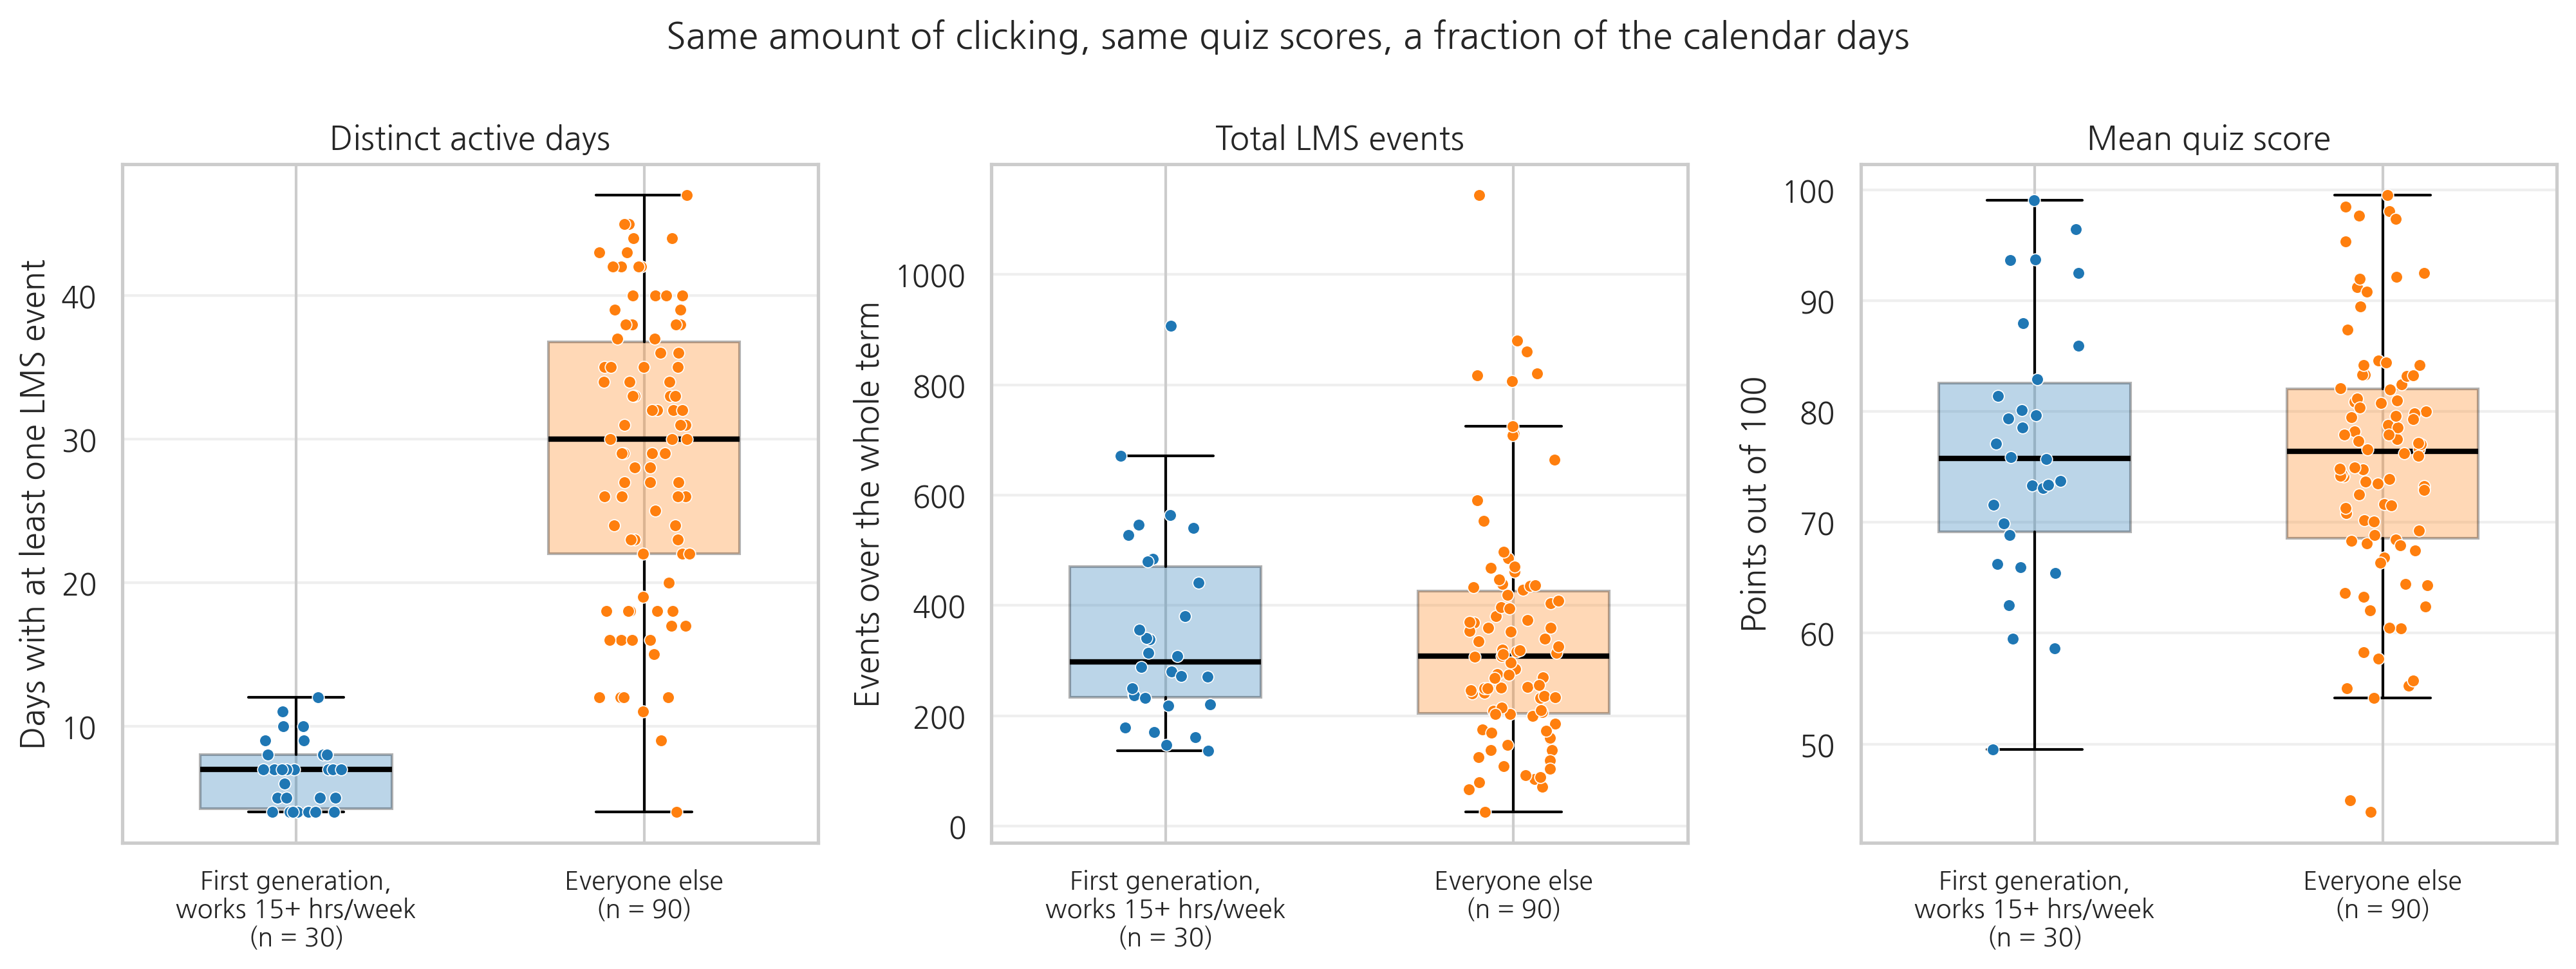

In [5]:
burst = ((model_table["first_gen"] == 1) &
         (model_table["work_hours_per_week"] >= 15)).to_numpy()
labels = ["First generation,\nworks 15+ hrs/week\n(n = 30)", "Everyone else\n(n = 90)"]
BLUE, ORANGE = "#1f77b4", "#ff7f0e"

summary = pd.DataFrame({
    "first gen, 15+ hrs (median)": model_table.loc[burst, ["active_days", "total_events", "mean_quiz", "prior_gpa"]].median().round(1),
    "everyone else (median)":      model_table.loc[~burst, ["active_days", "total_events", "mean_quiz", "prior_gpa"]].median().round(1),
})
summary["ratio"] = (summary.iloc[:, 0] / summary.iloc[:, 1]).round(2)
print("MEDIANS SIDE BY SIDE")
print(summary.to_string())

# ---------------------------------------------------------------- figure 2
panels = [
    ("active_days", "Distinct active days", "Days with at least one LMS event"),
    ("total_events", "Total LMS events", "Events over the whole term"),
    ("mean_quiz", "Mean quiz score", "Points out of 100"),
]
rng = np.random.default_rng(8100)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 5))

for ax, (col, title, ylab) in zip(axes, panels):
    data = [model_table.loc[burst, col].to_numpy(), model_table.loc[~burst, col].to_numpy()]
    box = ax.boxplot(data, patch_artist=True, widths=0.55, showfliers=False)
    for patch, colour in zip(box["boxes"], [BLUE, ORANGE]):
        patch.set_facecolor(colour)
        patch.set_alpha(0.30)
    for line in box["medians"]:
        line.set_color("black")
        line.set_linewidth(2)
    for i, values in enumerate(data, start=1):
        jitter = rng.uniform(-0.13, 0.13, len(values))
        ax.scatter(i + jitter, values, s=20, color=[BLUE, ORANGE][i - 1],
                   edgecolor="white", linewidth=0.4, zorder=3)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels, fontsize=9.5)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylab)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle("Same amount of clicking, same quiz scores, a fraction of the calendar days",
             fontsize=13.5, y=1.0)
fig.tight_layout()
plt.show()

**This is the whole lesson, in one chart.**

The two groups sit on top of each other on `total_events` and on `mean_quiz`. They are far apart on `active_days`, and only on `active_days`.

Here is the human version of that gap. A student working 25 hours a week studies on Sunday afternoon and Wednesday night, in long concentrated blocks. Same reading, same problem sets, same grades, fewer calendar squares with something in them. The feature `active_days` was quietly standing in for "has a schedule that looks like a full-time student's schedule."

And regularity is not a fake signal. For the other 90 students it genuinely predicts achievement. The model learned a real relationship and then applied it to a group where the relationship does not hold.

**Discuss:** what do you call a measure that means one thing in one group and something else in another? Where else in education do we use one?

### What the model actually sees

Same 120 students, plotted the way the model encounters them: two numbers each. The black rings mark the 25 students the activity-only model chose to flag.

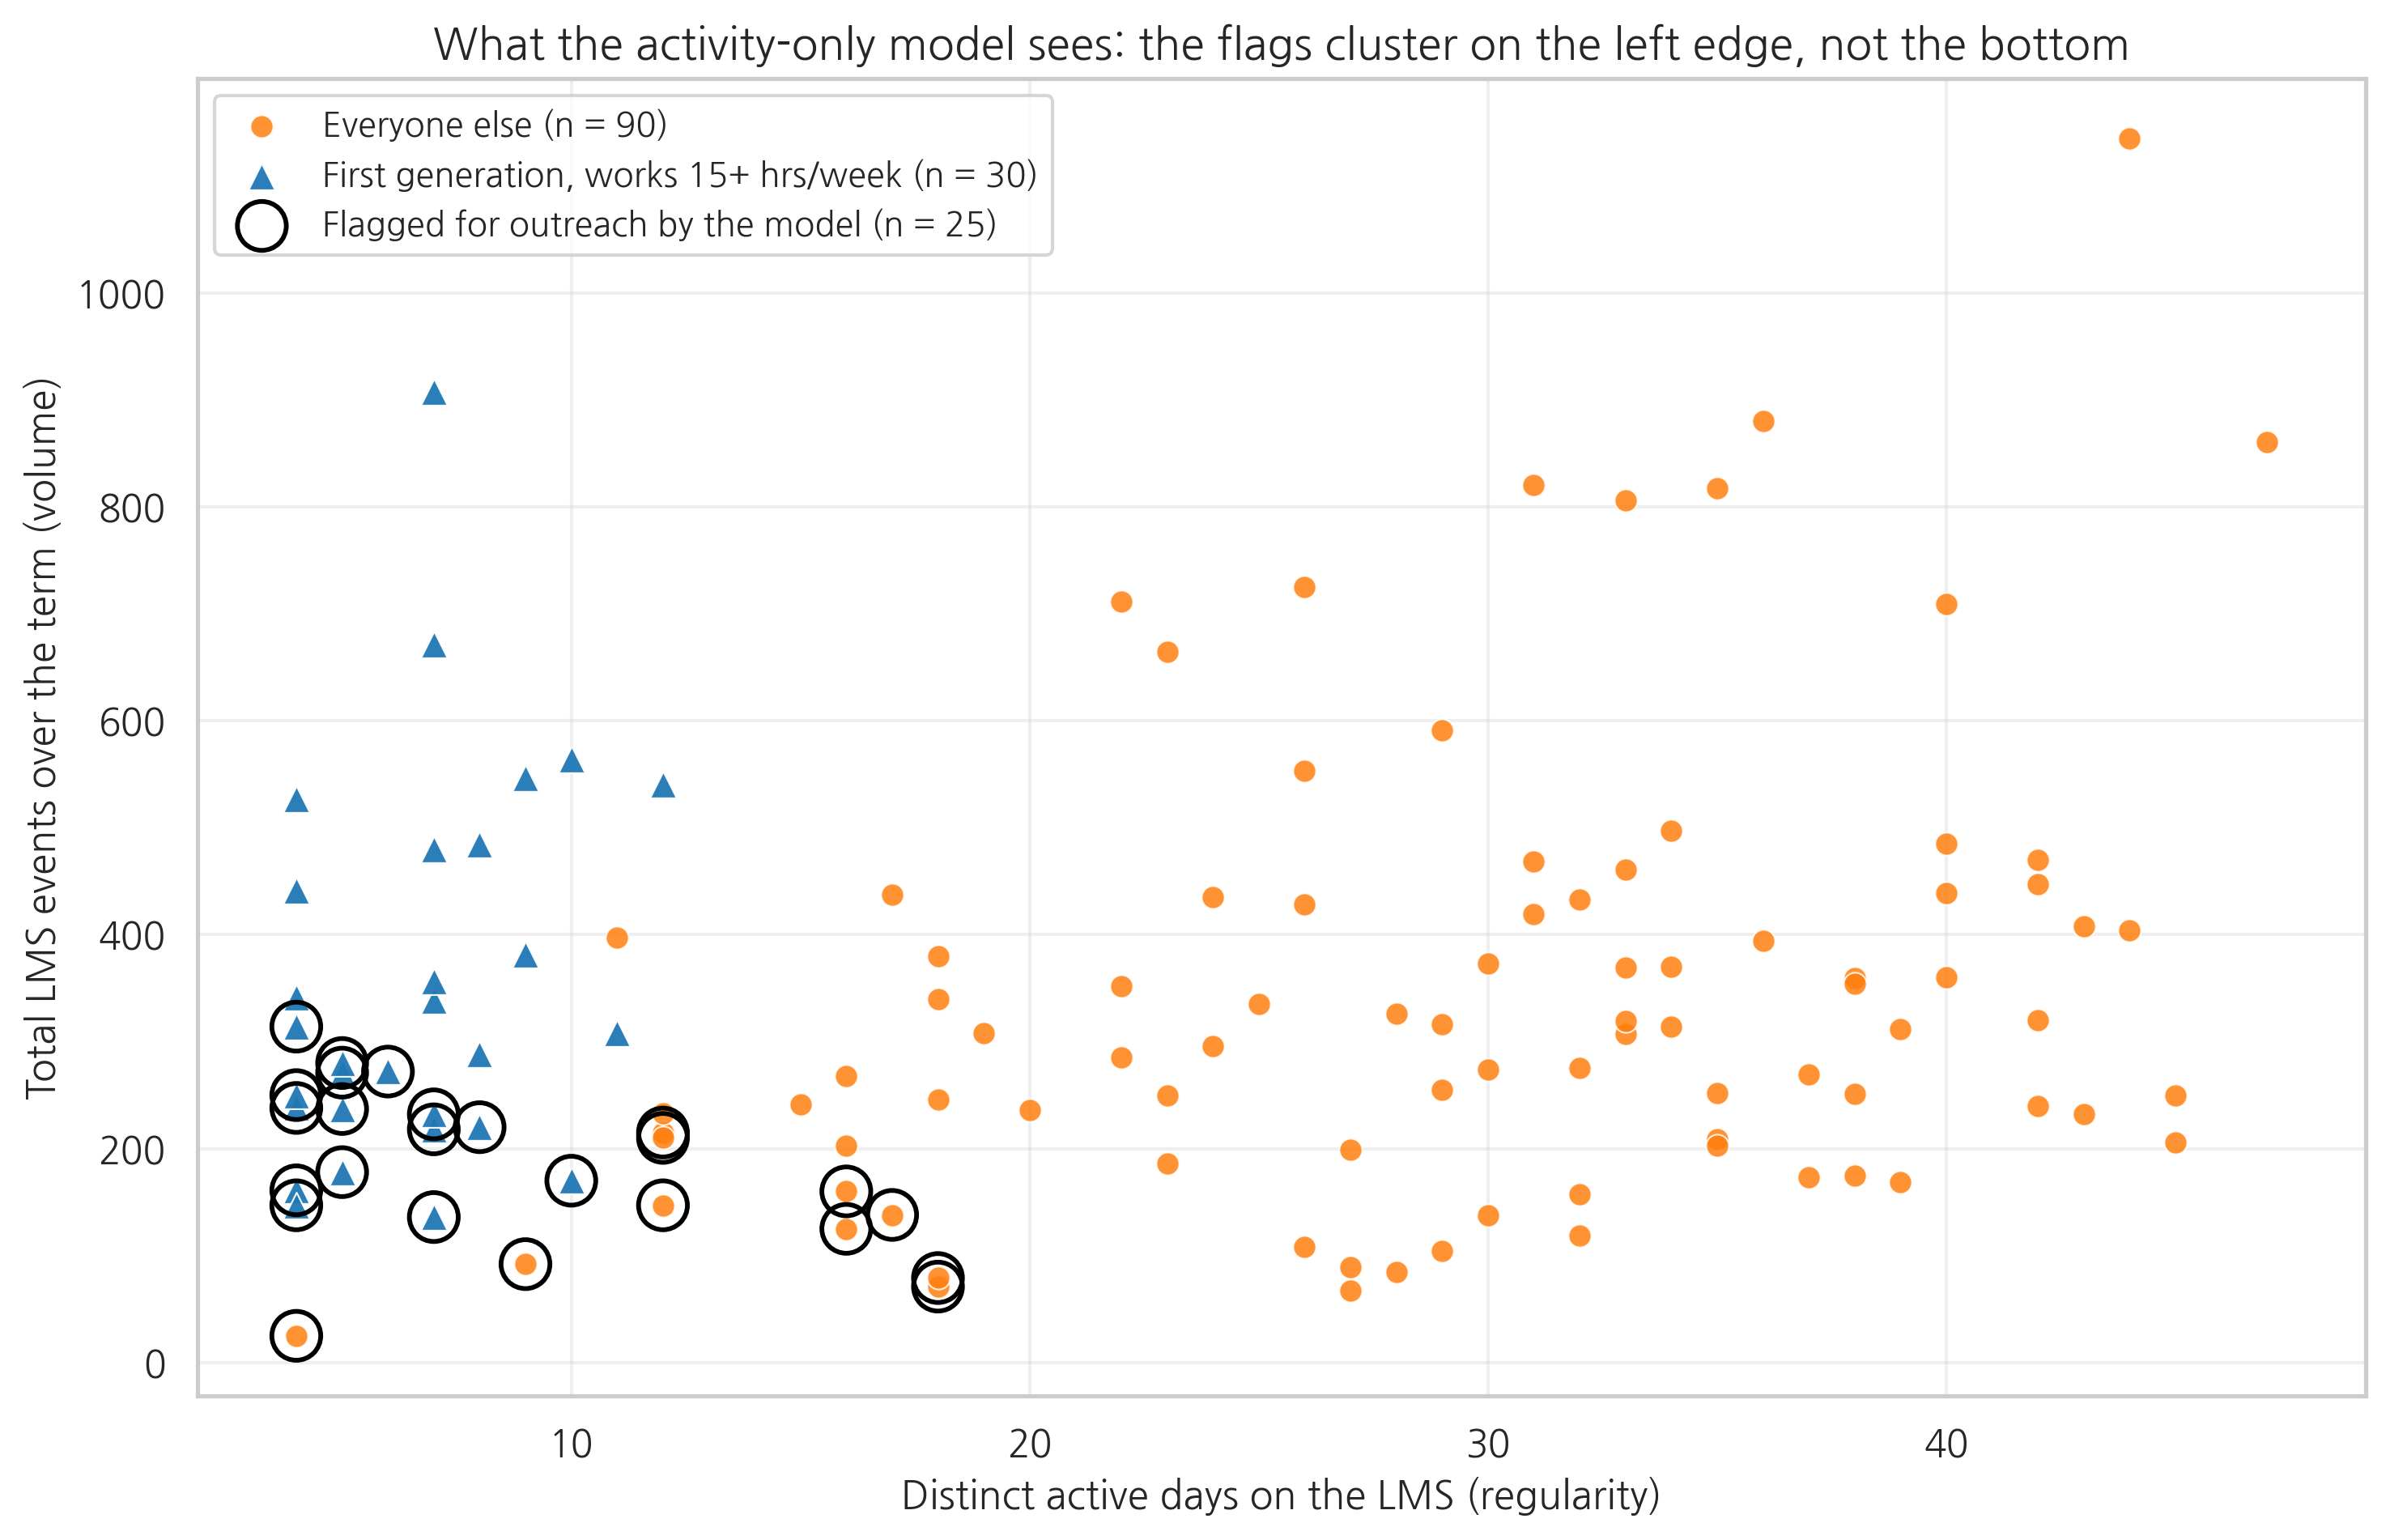

Students with 15 or fewer active days: 38
  ... of whom flagged: 20
  ... of whom first generation and working 15+ hrs: 30
Median total events, left edge vs everyone else: 272 vs 315


In [6]:
x = model_table["active_days"].to_numpy()
y_ev = model_table["total_events"].to_numpy()
flagged = flags_activity == 1

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(x[~burst], y_ev[~burst], marker="o", s=46, color=ORANGE, alpha=0.85,
           edgecolor="white", linewidth=0.5, label="Everyone else (n = 90)")
ax.scatter(x[burst], y_ev[burst], marker="^", s=62, color=BLUE, alpha=0.95,
           edgecolor="white", linewidth=0.5, label="First generation, works 15+ hrs/week (n = 30)")
ax.scatter(x[flagged], y_ev[flagged], s=210, facecolors="none", edgecolors="black",
           linewidths=1.4, label="Flagged for outreach by the model (n = 25)")

ax.set_xlabel("Distinct active days on the LMS (regularity)", fontsize=11.5)
ax.set_ylabel("Total LMS events over the term (volume)", fontsize=11.5)
ax.set_title("What the activity-only model sees: the flags cluster on the left edge, not the bottom",
             fontsize=13)
ax.legend(loc="upper left", frameon=True, fontsize=10)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

left_edge = x <= 15
print(f"Students with 15 or fewer active days: {left_edge.sum()}")
print(f"  ... of whom flagged: {flagged[left_edge].sum()}")
print(f"  ... of whom first generation and working 15+ hrs: {burst[left_edge].sum()}")
print(f"Median total events, left edge vs everyone else: "
      f"{np.median(y_ev[left_edge]):.0f} vs {np.median(y_ev[~left_edge]):.0f}")

**Look at where the rings are.** They hug the left edge, not the bottom. The model is not flagging students who did little. It is flagging students who did a normal amount of work on an unusual number of days.

A dot at the far left with 300 events is not an absent student. That is a compressed student. **What would a dashboard have to show a teacher for the difference between "absent" and "compressed" to be visible?** Hold that question for week 4, when you build the dashboard.

## ✏️ Your turn 1: the number that is not in the model

`CASELOAD` is how many students the advising office can actually contact. It is not a model setting. It is a staffing budget, and it decides who gets a phone call just as much as the algorithm does.

The cell below already works, so you can just run it. Then change the `25` to something else (try `10`, then `50`) and re-run **this cell only**. Nothing later in the notebook depends on it, so you cannot break anything.

Watch what happens to the two false positive rates as the caseload grows.

In [7]:
MY_CASELOAD = 25    # ✏️ change this number, then re-run this cell (try 10, then 50)

flags_try = flag_top_k(scores_activity, MY_CASELOAD)
compare = audit_table(flags_try).loc[["First gen AND 15+ hrs", "Everyone else"]]

print(f"Caseload = {MY_CASELOAD} students contacted, overall accuracy = "
      f"{(flags_try == y_true).mean():.3f}\n")
print(compare[["not at risk (n)", "false positive rate",
               "at risk (n)", "false negative rate"]].to_string())
gap = (compare.loc["First gen AND 15+ hrs", "false positive rate"]
       - compare.loc["Everyone else", "false positive rate"])
print(f"\nFalse positive rate gap: {gap:+.3f}")

Caseload = 25 students contacted, overall accuracy = 0.742

                       not at risk (n)  false positive rate  at risk (n)  false negative rate
group                                                                                        
First gen AND 15+ hrs               21                0.333            9                0.111
Everyone else                       65                0.062           25                0.760

False positive rate gap: +0.271


## 📊 5. Redesign round: change the feature set, run the same audit

Here is the move that matters, and it is smaller than people expect.

We are **not** going to change the algorithm. Logistic regression was never the problem. It did what it was asked to do, on the numbers it was given, and it did it competently. We are going to change **what we let the model look at.**

That is a design decision. Design decisions have authors, they get written down, and they can be revised on a Tuesday afternoon by somebody with the authority to revise them. That is a very different kind of object from "the algorithm is biased."

The redesigned model gets `prior_gpa`, a direct measure of prior achievement, plus a small number of behavioural features that describe **what a student produced** rather than **how evenly they spread it across the calendar.**

## ✏️ Your turn 2: pick the feature set

The line in the next cell already contains a set that works, so you can run the cell as it is and see the redesign. Then come back, add or remove one column name, and re-run to see what your choice does to the gap.

Columns you can choose from:

`prior_gpa`, `total_events`, `active_days`, `submit`, `page_view`, `video_play`, `video_pause`, `forum_view`, `assignment_view`, `login`

Two questions worth holding while you choose:

1. Does this feature describe something the student **did**, or something their **circumstances** did to them?
2. If a student were told this feature was being used to decide whether they get a phone call, would they feel supported or surveilled?

(If you type a column name that does not exist, the cell will tell you and quietly fall back to the default so the rest of the notebook keeps working.)

Activity-only features : total_events, active_days, video_play, forum_view
  accuracy 0.742
Redesigned features    : prior_gpa, total_events, submit
  accuracy 0.858

AUDIT OF THE REDESIGNED MODEL
                       students  not at risk (n)  false positive rate  at risk (n)  false negative rate
group                                                                                                  
First generation             39               27                0.037           12                0.250
Continuing generation        81               59                0.051           22                0.455
Works 15+ hrs/week           40               30                0.067           10                0.200
Works under 15 hrs           80               56                0.036           24                0.458
First gen AND 15+ hrs        30               21                0.048            9                0.222
Everyone else                90               65                0.046      

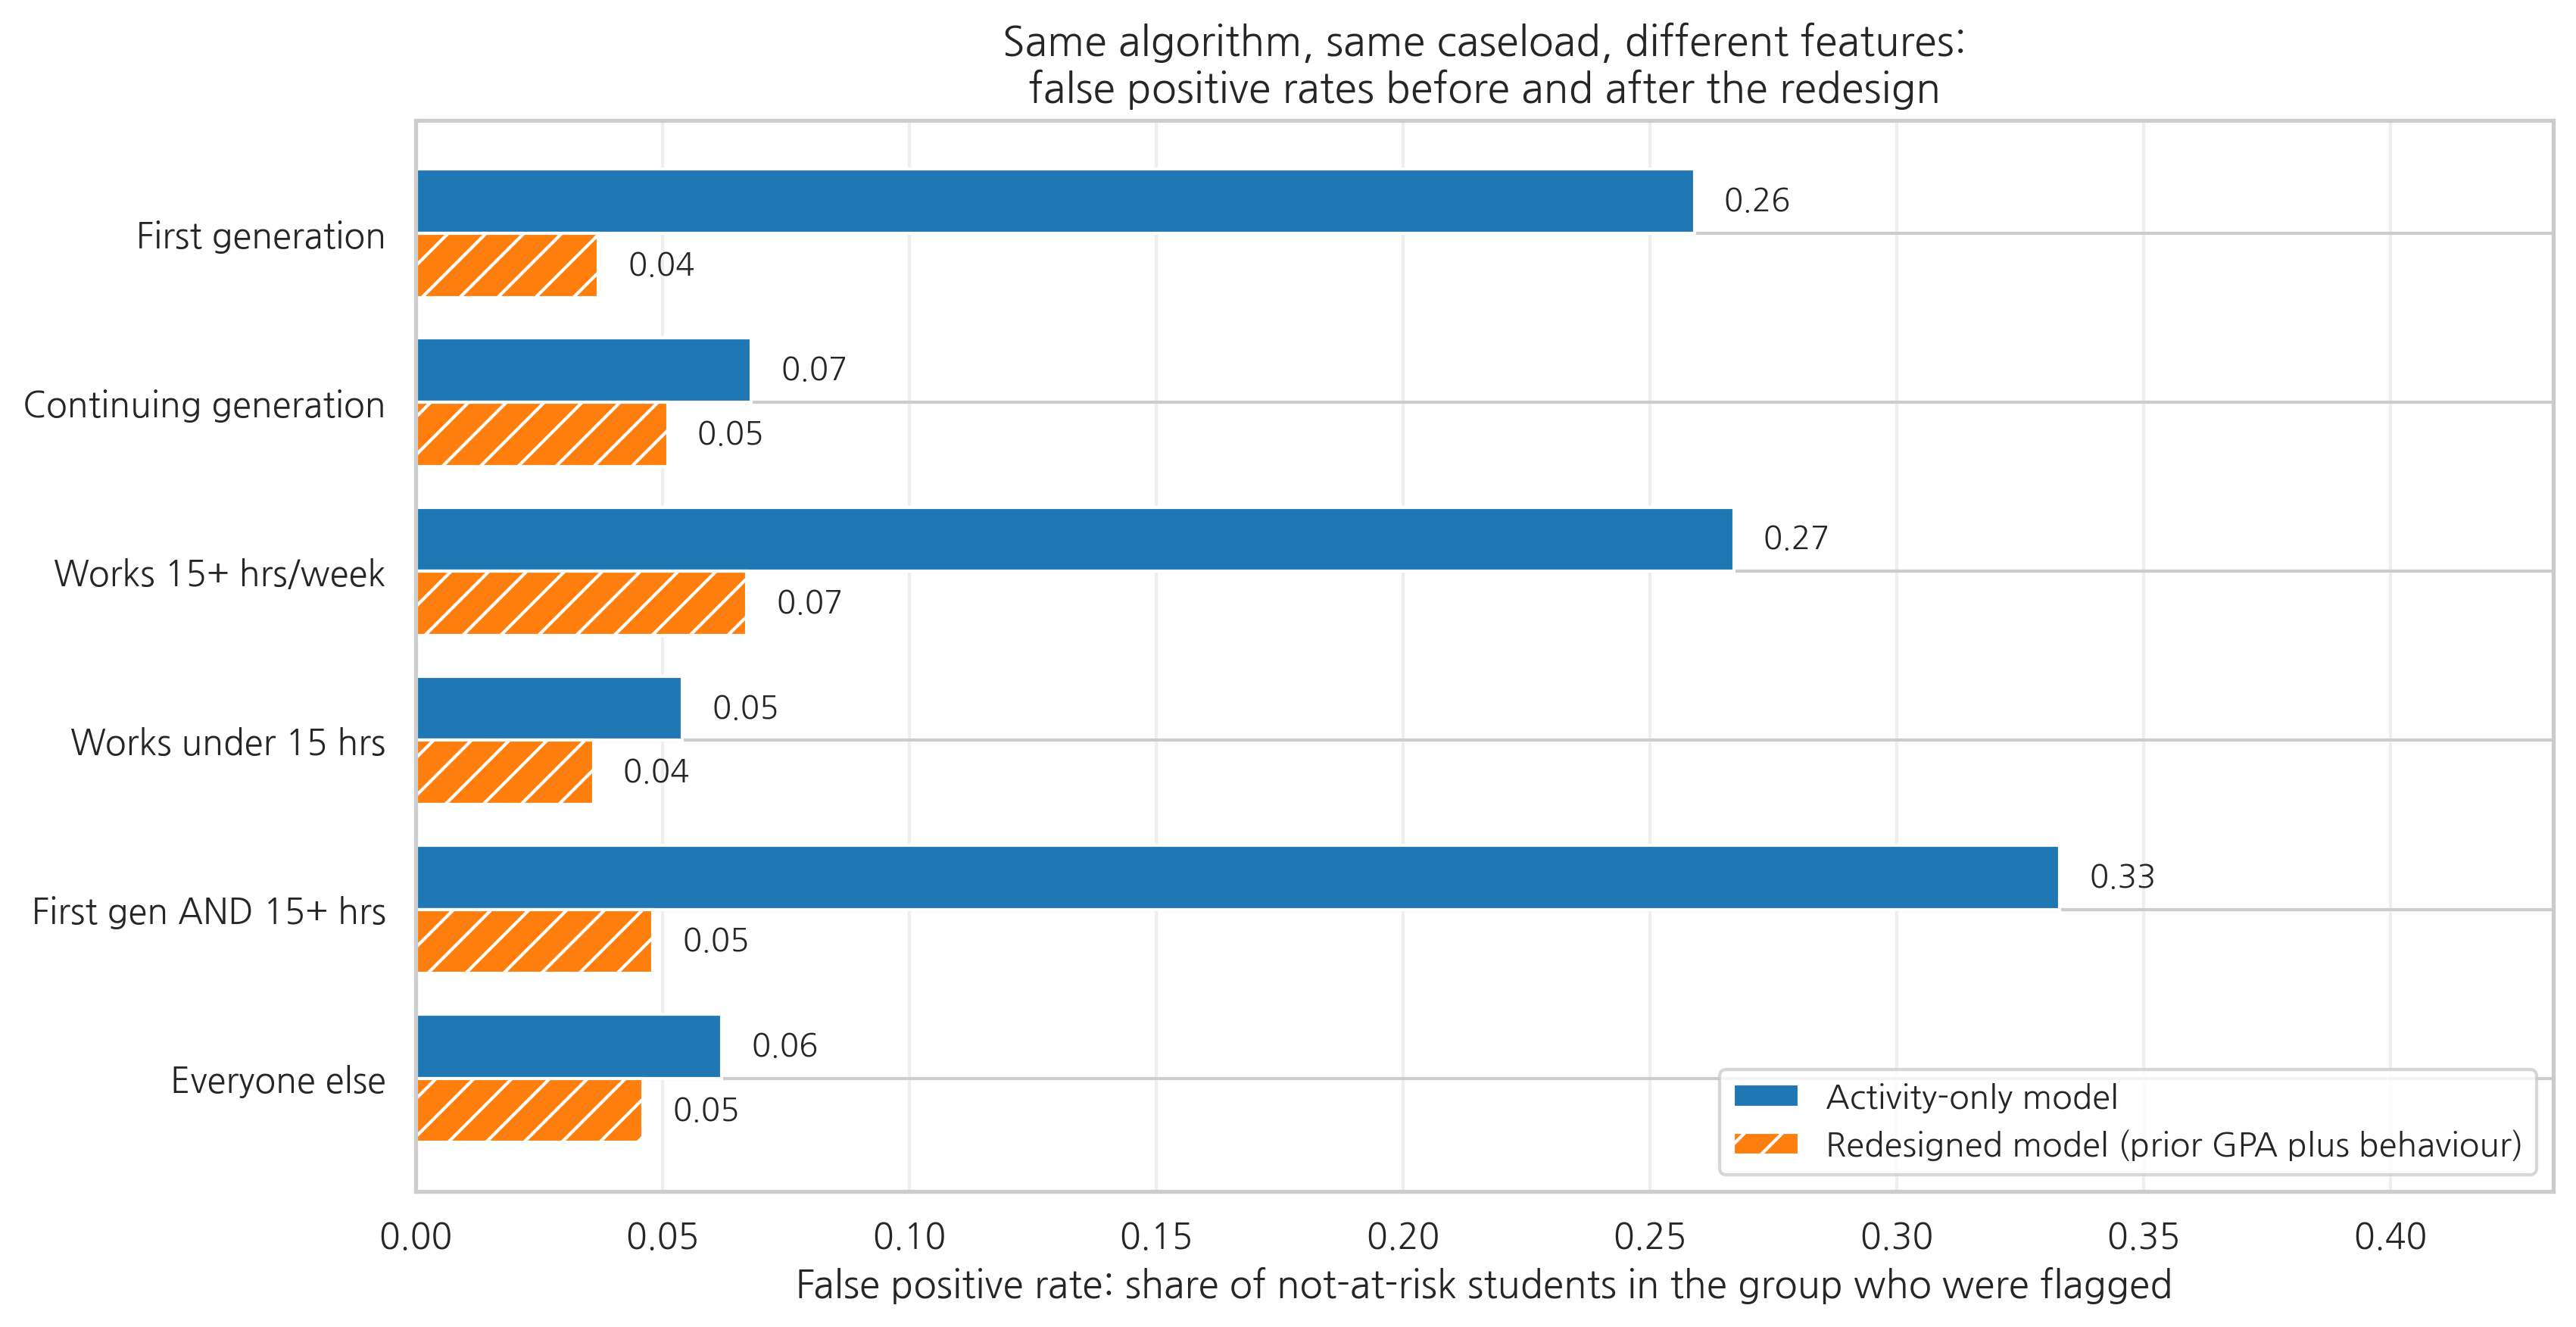

In [8]:
# ✏️ TODO: choose the features for the redesigned model.
#          The default below already works. Change it once you have run it as is.
redesign_features = ["prior_gpa", "total_events", "submit"]


# --- a friendly safety net: unknown column names fall back to the default ---
DEFAULT_REDESIGN = ["prior_gpa", "total_events", "submit"]
usable = [c for c in redesign_features if c in model_table.columns]
if len(usable) != len(redesign_features) or not usable:
    unknown = [c for c in redesign_features if c not in model_table.columns]
    print(f"Heads up: {unknown} is not a column in the table, so we used the default set.")
    print(f"Choose from: {', '.join(sorted(c for c in model_table.columns if c not in ['student_id','first_name','last_name','gender','major_area','mean_quiz','at_risk']))}\n")
    usable = DEFAULT_REDESIGN

scores_redesign = risk_scores(usable)
flags_redesign = flag_top_k(scores_redesign, CASELOAD)
audit_redesign = audit_table(flags_redesign)

acc_redesign = (flags_redesign == y_true).mean()
print(f"Activity-only features : {', '.join(ACTIVITY_FEATURES)}")
print(f"  accuracy {accuracy:.3f}")
print(f"Redesigned features    : {', '.join(usable)}")
print(f"  accuracy {acc_redesign:.3f}\n")
print("AUDIT OF THE REDESIGNED MODEL")
print(audit_redesign.to_string())

def fpr_gap(table, a="First gen AND 15+ hrs", b="Everyone else"):
    return table.loc[a, "false positive rate"] - table.loc[b, "false positive rate"]

print(f"\nFalse positive rate gap (first gen and 15+ hrs, minus everyone else)")
print(f"  activity-only model : {fpr_gap(audit_activity):+.3f}")
print(f"  redesigned model    : {fpr_gap(audit_redesign):+.3f}")

# ---------------------------------------------------------------- figure 4
order = list(GROUPS.keys())
ypos = np.arange(len(order))
height = 0.38

fig, ax = plt.subplots(figsize=(11.5, 6))
ax.barh(ypos - height / 2, audit_activity.loc[order, "false positive rate"],
        height=height, color=BLUE, label="Activity-only model")
ax.barh(ypos + height / 2, audit_redesign.loc[order, "false positive rate"],
        height=height, color=ORANGE, hatch="//", edgecolor="white",
        label="Redesigned model (prior GPA plus behaviour)")

for i, name in enumerate(order):
    ax.text(audit_activity.loc[name, "false positive rate"] + 0.006, i - height / 2,
            f"{audit_activity.loc[name, 'false positive rate']:.2f}", va="center", fontsize=10)
    ax.text(audit_redesign.loc[name, "false positive rate"] + 0.006, i + height / 2,
            f"{audit_redesign.loc[name, 'false positive rate']:.2f}", va="center", fontsize=10)

ax.set_yticks(ypos)
ax.set_yticklabels(order, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("False positive rate: share of not-at-risk students in the group who were flagged")
ax.set_title("Same algorithm, same caseload, different features:\nfalse positive rates before and after the redesign",
             fontsize=13)
ax.set_xlim(0, max(audit_activity["false positive rate"].max(),
                   audit_redesign["false positive rate"].max()) + 0.10)
ax.legend(loc="lower right", fontsize=10.5)
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

**Compare the pairs of bars.** The gap that was the whole story a moment ago is close to gone, and the overall accuracy went **up**, not down.

That last part is worth sitting with, because the usual argument against auditing a model is that fairness costs accuracy. Here it did not, and the reason is not luck: the activity-only model was spending its attention on a feature that measured schedule rather than learning. Removing it made the model both fairer and better at its actual job.

**Discuss with your neighbour:** you now have two models. One is 74 percent accurate and calls the wrong students. One is 86 percent accurate and calls fewer of them. If the first one had already been running for three years and a vendor contract were attached to it, what would it actually take, inside a real university, to switch?

### One caution before this feels too much like a solution

`prior_gpa` is not innocent either.

A GPA carries the history of every school a student attended before this one, and those schools were not equally resourced, equally staffed, or equally forgiving. Swapping a feature that encodes **how many hours you work for pay** for a feature that encodes **which high school you went to** is a trade, not a fix. It moves the harm rather than removing it, and it moves it somewhere our audit was not looking.

Which points at the honest limit of what we just did:

- We audited **two** attributes, `first_gen` and `work_hours_per_week`, because we suspected them. A gap you never measured is not a gap you fixed.
- We audited a model. We did not audit the **intervention** the flag triggers. A warm, well-staffed outreach conversation and an automatic "academic concern" note in a student's file are the same flag attached to very different consequences.
- Nobody in this notebook asked the 120 students whether they wanted to be scored at all.

Week 4 puts this model on a dashboard and asks what a teacher would do with it. Keep the list above.

## ✏️ Your turn 3 (stretch): audit a group nobody asked about

The gap we found was one we went looking for. This cell lets you point the same audit at any column of the roster.

`multilingual` is the working default, so the cell runs as is. Try `gender`, or `major_area`, and note what happens to the size of the cells you are comparing.

In [9]:
AUDIT_COLUMN = "multilingual"   # ✏️ try "gender", "major_area", or "first_gen"

if AUDIT_COLUMN not in model_table.columns:
    print(f"'{AUDIT_COLUMN}' is not a column, so we used 'multilingual' instead.")
    AUDIT_COLUMN = "multilingual"

custom_groups = {
    f"{AUDIT_COLUMN} = {value}": (model_table[AUDIT_COLUMN] == value).to_numpy()
    for value in sorted(model_table[AUDIT_COLUMN].unique())
}

print(f"ACTIVITY-ONLY MODEL, audited by {AUDIT_COLUMN}")
print(audit_table(flags_activity, custom_groups).to_string())
print(f"\nREDESIGNED MODEL, audited by {AUDIT_COLUMN}")
print(audit_table(flags_redesign, custom_groups).to_string())
print("\nSmall 'n at risk' or 'n not at risk' means the rate above it is fragile. "
      "Say so out loud before you report it.")

ACTIVITY-ONLY MODEL, audited by multilingual
                  students  not at risk (n)  false positive rate  at risk (n)  false negative rate
group                                                                                             
multilingual = 0        96               68                0.132           28                0.607
multilingual = 1        24               18                0.111            6                0.500

REDESIGNED MODEL, audited by multilingual
                  students  not at risk (n)  false positive rate  at risk (n)  false negative rate
group                                                                                             
multilingual = 0        96               68                0.044           28                0.429
multilingual = 1        24               18                0.056            6                0.167

Small 'n at risk' or 'n not at risk' means the rate above it is fragile. Say so out loud before you report it.


## 💬 Reflection

Bring answers to the discussion block. These are for talking, not for uploading.

**1. The bias was in the feature, not the algorithm.** Tsai and Martinez-Maldonado (2022), in "Human-centered approaches to data-informed feedback," argue that the humans around a system are part of the system. In this notebook the harm entered at a choice about which columns to use. Who, in a real university, makes that choice? Who currently has the standing to challenge it, and who should?

**2. What does the audit not cover?** Holstein and Doroudi (2022), "Equity and artificial intelligence in education," push past narrow definitions of algorithmic fairness. We equalised one error rate across two attributes. Name a form of inequity that this notebook's audit is structurally incapable of detecting, no matter how many groups we add to the table.

**3. The flag lands on a person.** Lee and Gargroetzi (2023), "'It's like a double-edged sword': Mentor perspectives on ethics and responsibility in a learning analytics-supported virtual mentoring program," found mentors holding real ambivalence about being handed information about the students they were supporting. Imagine you are the advisor who receives our list of 25 names. What are you told about how the list was made? What would you want to be told? What would you do differently on Monday if the answer were "nothing"?

**4. Optional, connecting to the fourth reading.** Borchers, Liu, Lee, and Zhang (2024), "Ethical AIED and AIED ethics," ask what it would take for ethical frameworks and technical research to actually meet. Where in this 30-minute workflow would a framework have had to intervene to prevent the harm, and which of those points already had somebody standing at it?

**5. For your own project.** Write one sentence naming a feature you are considering using in your course research project, and one sentence saying who it might mean something different for.

## ✅ Before you leave

**There is nothing to submit to Canvas this week.** Week 3 is a launch: we run the audit together in class and carry it into the discussion block. The first Canvas deliverable is Mini Project 1, due in week 4.

- [ ] Ran every cell from the top with no errors (`Runtime > Restart and run all` if in doubt)
- [ ] Changed `MY_CASELOAD` at least once and watched the false positive rates move
- [ ] Ran the redesign cell, and know which features are in your version of the model
- [ ] Can say in one sentence where the bias entered and who has the authority to revise it
- [ ] Have one question ready for our guest, Hansol Lee (Stanford University)
- [ ] Saved a copy if you edited anything you want to keep (`File > Save a copy in Drive`)

**A note on AI use.** If you used an AI assistant anywhere in this notebook, to explain a line of code, to check your reading of a chart, or to draft a reflection, save that exchange now. Starting with Mini Project 1 in week 4, the course AI policy requires you to upload your AI interaction log plus a short reflection alongside the notebook, in the Canvas "AI Reflection" submission. Undisclosed AI use is an Honor Code violation. Building the habit this week, when nothing is being graded, is much cheaper than starting it under a deadline.

## Appendix: solutions to the ✏️ Your turn cells

Read these after you have tried the cells yourself. The point is not the code, it is what the numbers do.

### Your turn 1: the caseload

```python
MY_CASELOAD = 10     # then 25, then 50
```

As the caseload grows, the model has to reach further down its ranked list, so both groups pick up more false positives. What does not change is the ordering: the activity-only model puts first generation students who work long hours near the top of its list at every caseload, so they absorb the false positives first and keep absorbing them.

The lesson: shrinking a caseload does not fix a biased ranking. It concentrates it. A small caseload can look "safe" because it flags few people, while being the most disparate policy on offer.

### Your turn 2: the feature set

```python
redesign_features = ["prior_gpa", "total_events", "submit"]   # the default
```

Things worth trying and what to expect:

```python
redesign_features = ["prior_gpa"]
# Accuracy stays high. The false positive gap shrinks a lot but does not vanish,
# because prior GPA is itself unevenly distributed. Simplicity is not neutrality.

redesign_features = ["prior_gpa", "active_days"]
# The gap comes back. active_days is the feature that carried the harm,
# and adding a good feature next to a harmful one does not cancel it out.

redesign_features = ["prior_gpa", "total_events", "submit", "forum_view"]
# Roughly similar to the default. Not every feature you add changes anything,
# which is its own argument for adding fewer of them.
```

The move to notice across all of these: the algorithm never changed. Every difference you produced came from a decision a person made about what the model was allowed to look at.

### Your turn 3: auditing another group

```python
AUDIT_COLUMN = "multilingual"   # then "gender", then "major_area"
```

Two things usually show up. First, most columns show no dramatic gap, which is the normal result and worth experiencing, because an audit that only ever confirms your suspicion is not an audit. Second, `major_area` splits 120 students into six groups, so some cells hold only a handful of not-at-risk students and a single flagged student swings the rate by 20 points. Reporting that number without its denominator would be the kind of confident, fragile claim this course keeps asking you to refuse.